# Bike Share Demand — Model Training

Predict hourly departures per station so ops can rebalance bikes before stations run dry.
Regression at the **station-hour** grain.

**Data** (produced by the Spark pipeline, see `spark/notebooks/split.ipynb`) — chronological split:

| split | source | period | rows |
|---|---|---|---|
| train | `data/featured/train/` | 2019–2022 | 51.4M |
| test  | `data/featured/test/`  | 2023      | 12.9M |

We read the **partitioned Parquet**, not the exported CSVs — it is ~117 MB on disk vs 7.2 GB,
and supports column/predicate pushdown.

**Business problem:** `docs/ml/01-problem.md`

---

### Three known data defects, handled below

| # | Defect | Handling |
|---|---|---|
| 1 | Duplicate `(station_id, start_date, hour)` rows with conflicting `lag_1h` | dedupe on read (Step 3) |
| 2 | `member_ratio` is **target leakage** — computed from the same hour's trips, and null exactly when `trip_count == 0` | drop from features |
| 3 | `is_holiday` only populated for 2019–2020 (hard-coded list in `ml-ds.ipynb` stops at 2020) so train/test disagree on its meaning | drop from features |

Defects 1 and 3 are upstream bugs; fixing them at source means re-materializing 64M rows,
so they are worked around here. See the plan's *Deferred* section.

## Step 1 — Environment

Install dependencies from a terminal, then restart the kernel.

```bash
cd ml
pip install --only-binary=:all: -r requirements.txt
```

Start the MLflow tracking server (Postgres backend, local artifact store) — see
`mlflow/README.md`:

```bash
docker compose -f mlflow/docker-compose.yml up -d --build
```

The UI is at http://localhost:5000. Every run below is logged there; if the server is
not reachable the notebook still trains and writes `ml/artifacts/`, it just skips
tracking (see `MLFLOW_ENABLED`).

In [35]:
import json
import os
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import pyarrow.dataset as ds
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
N_STATIONS = 150          # busiest stations to keep; full data won't fit in pandas
VALIDATION_YEAR = 2022    # held out of train for tuning; test (2023) stays untouched

# Notebook lives in ml/, data lives at the repo root.
ROOT = Path.cwd().parent if Path.cwd().name == "ml" else Path.cwd()
FEATURED = ROOT / "data" / "featured"
TRAIN_DIR, TEST_DIR = FEATURED / "train", FEATURED / "test"
ARTIFACTS = ROOT / "ml" / "artifacts"
ARTIFACTS.mkdir(parents=True, exist_ok=True)

for d in (TRAIN_DIR, TEST_DIR):
    assert d.exists(), f"missing {d} — run spark/notebooks/split.ipynb first"

print(f"root      {ROOT}")
print(f"train     {TRAIN_DIR}")
print(f"test      {TEST_DIR}")
print(f"artifacts {ARTIFACTS}")

# --- MLflow tracking -------------------------------------------------------
# The server proxies artifact storage (--serve-artifacts), so the client needs
# nothing but this URI. Tracking is best-effort: a dead server must not cost us
# a 4-minute training run, so we probe once here and degrade to a no-op.
TRACKING_URI = os.environ.get("MLFLOW_TRACKING_URI", "http://localhost:5000")
EXPERIMENT = "bike-share-demand"

# MLflow prints a "🏃 View run ..." line on every run end. On a Windows cp1252
# console that emoji raises UnicodeEncodeError and kills the run, so suppress it
# — the cells below print the URLs that actually matter.
os.environ.setdefault("MLFLOW_SUPPRESS_PRINTING_URL_TO_STDOUT", "true")

mlflow.set_tracking_uri(TRACKING_URI)
try:
    mlflow.set_experiment(EXPERIMENT)
    MLFLOW_ENABLED = True
    print(f"\nmlflow    {TRACKING_URI}  experiment={EXPERIMENT!r}")
except Exception as exc:  # server down, wrong port, etc.
    MLFLOW_ENABLED = False
    print(f"\nmlflow    UNAVAILABLE at {TRACKING_URI} ({type(exc).__name__}) — tracking disabled")
    print("          start it with: docker compose -f mlflow/docker-compose.yml up -d")

2026/07/29 16:27:09 INFO mlflow.tracking.fluent: Experiment with name 'bike-share-demand' does not exist. Creating a new experiment.


root      c:\Users\simon\OneDrive\Tech\Github\ml-shared-bike
train     c:\Users\simon\OneDrive\Tech\Github\ml-shared-bike\data\featured\train
test      c:\Users\simon\OneDrive\Tech\Github\ml-shared-bike\data\featured\test
artifacts c:\Users\simon\OneDrive\Tech\Github\ml-shared-bike\ml\artifacts

mlflow    http://localhost:5000  experiment='bike-share-demand'


## Step 2 — Load from Parquet

51M rows will not fit in pandas, so we keep **every hour for the busiest `N_STATIONS`**
rather than randomly sampling rows. Random sampling would shred the lag/rolling structure
and over-represent the ~79% zero rows; a station subset keeps each station's hourly series
intact, which is what a demand model needs.

Two passes:
1. Read only `station_id` + `trip_count` to rank stations by total volume.
2. Re-read both splits filtered to that subset, with column pushdown.

In [36]:
# Pass 1 — rank stations by total volume (reads 2 columns only).
train_ds = ds.dataset(TRAIN_DIR, format="parquet", partitioning="hive")
test_ds = ds.dataset(TEST_DIR, format="parquet", partitioning="hive")

print("parquet schema:")
print(train_ds.schema.to_string(show_field_metadata=False))

volume = (
    train_ds.to_table(columns=["station_id", "trip_count"])
    .to_pandas()
    .groupby("station_id")["trip_count"]
    .sum()
    .sort_values(ascending=False)
)
TOP_STATIONS = volume.head(N_STATIONS).index.tolist()

share = volume.head(N_STATIONS).sum() / volume.sum()
print(f"\n{len(volume):,} stations total; keeping top {N_STATIONS}")
print(f"they carry {share:.1%} of all training trips")

parquet schema:
station_id: int32
start_date: date32[day]
hour: int32
trip_count: int64
quarter: int32
day_of_week: int32
is_weekend: int32
is_holiday: int32
hour_sin: double
hour_cos: double
dow_sin: double
dow_cos: double
lag_1h: int64
lag_24h: int64
lag_168h: int64
roll_mean_24h: double
roll_mean_168h: double
member_ratio: double
year: int32
month: int32
-- schema metadata --
org.apache.spark.version: '3.5.0'
org.apache.spark.sql.parquet.row.metadata: '{"type":"struct","fields":[{"' + 1201

856 stations total; keeping top 150
they carry 55.5% of all training trips


In [37]:
# Pass 2 — load both splits, filtered to the station subset.
# `year` is a hive partition key (from the directory path), not a file column.
READ_COLUMNS = [
    "station_id", "start_date", "hour", "trip_count", "year",
    "quarter", "day_of_week", "is_weekend",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "lag_1h", "lag_24h", "lag_168h", "roll_mean_24h", "roll_mean_168h",
]

station_filter = ds.field("station_id").isin(TOP_STATIONS)


def load(dataset, name):
    df = dataset.to_table(columns=READ_COLUMNS, filter=station_filter).to_pandas()
    mem = df.memory_usage(deep=True).sum() / 1024**3
    print(f"{name:6} {len(df):>10,} rows  {mem:5.2f} GB")
    return df


train_raw = load(train_ds, "train")
test_raw = load(test_ds, "test")

train   5,234,400 rows   0.70 GB
test    1,314,000 rows   0.18 GB


## Step 3 — Clean

The grain is supposed to be one row per `(station_id, start_date, hour)`, but the upstream
join fans out: **every row appears exactly twice** (verified — 50.0% duplication over a
3M-row scan). `trip_count` always agrees between copies; `lag_1h` differs in ~51% of pairs.

Which copy is right? Reconstructing the true previous-hour `trip_count` and comparing:

| rule | correct |
|---|---|
| **keep first copy** | **100.0%** |
| keep second copy | 0.0% |
| keep larger `lag_1h` | 49.4% |
| keep smaller `lag_1h` | 50.6% |

So `keep="first"` recovers the correct lag exactly, while any value-based heuristic is a
coin flip. Parquet row order is deterministic, so this is stable across runs.

We then drop the two unusable columns and assert the split is genuinely chronological.

In [38]:
GRAIN = ["station_id", "start_date", "hour"]


def clean(df, name):
    before = len(df)
    df = df.drop_duplicates(subset=GRAIN, keep="first").copy()
    dropped = before - len(df)
    print(f"{name:6} {before:>10,} -> {len(df):>10,}  ({dropped:,} dupes, {dropped/before:.1%})")

    df["start_date"] = pd.to_datetime(df["start_date"])
    df["station_id"] = df["station_id"].astype("category")
    return df.sort_values(GRAIN).reset_index(drop=True)


train = clean(train_raw, "train")
test = clean(test_raw, "test")

# Test stations must be a subset of train's, or the categorical encoding breaks.
test["station_id"] = test["station_id"].cat.set_categories(train["station_id"].cat.categories)
assert not test["station_id"].isna().any(), "test contains stations unseen in train"

del train_raw, test_raw

train   5,234,400 ->  5,234,400  (0 dupes, 0.0%)
test    1,314,000 ->  1,314,000  (0 dupes, 0.0%)


In [39]:
# Leakage guards — these must hold before any model sees the data.
assert train["start_date"].max() < test["start_date"].min(), "train/test dates overlap"
assert not train.duplicated(subset=GRAIN).any(), "train still has duplicate station-hours"
assert not test.duplicated(subset=GRAIN).any(), "test still has duplicate station-hours"

print(f"train  {train['start_date'].min():%Y-%m-%d} .. {train['start_date'].max():%Y-%m-%d}")
print(f"test   {test['start_date'].min():%Y-%m-%d} .. {test['start_date'].max():%Y-%m-%d}")
print()
print(f"train  mean={train['trip_count'].mean():.3f}  "
      f"zero_share={(train['trip_count'] == 0).mean():.1%}  max={train['trip_count'].max()}")
print(f"test   mean={test['trip_count'].mean():.3f}  "
      f"zero_share={(test['trip_count'] == 0).mean():.1%}  max={test['trip_count'].max()}")

train  2019-01-08 .. 2022-12-31
test   2023-01-01 .. 2023-12-31

train  mean=1.397  zero_share=55.0%  max=126
test   mean=2.092  zero_share=44.1%  max=112


## Step 4 — Feature set

**Excluded on purpose:**

- `member_ratio` — leakage. Derived from the same hour's trips and null exactly when
  `trip_count == 0`, so its missingness alone reveals the target.
- `is_holiday` — only populated for 2019–2020 (the hard-coded `ONTARIO_HOLIDAYS` list in
  `ml-ds.ipynb` stops at 2020). Train and test therefore disagree on what the flag means.
- `start_date`, `year`, `month` — time index and partition keys, not features. Keeping raw
  `year` would let the model latch onto a trend it cannot extrapolate to 2023.

In [40]:
TARGET = "trip_count"
CATEGORICAL = ["station_id"]
NUMERIC = [
    "hour", "quarter", "day_of_week", "is_weekend",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "lag_1h", "lag_24h", "lag_168h", "roll_mean_24h", "roll_mean_168h",
]
FEATURES = CATEGORICAL + NUMERIC

BANNED = {"member_ratio", "is_holiday", "start_date", "year", "month"}
assert not BANNED & set(FEATURES), f"banned column leaked into features: {BANNED & set(FEATURES)}"

# Chronological validation split: fit on 2019-2021, tune on 2022. Never random-split a
# time series. Test (2023) is untouched until the final evaluation.
fit_mask = train["year"] < VALIDATION_YEAR
X_fit, y_fit = train.loc[fit_mask, FEATURES], train.loc[fit_mask, TARGET]
X_val, y_val = train.loc[~fit_mask, FEATURES], train.loc[~fit_mask, TARGET]
X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

print(f"fit    {len(X_fit):>9,}  (2019-{VALIDATION_YEAR - 1})")
print(f"val    {len(X_val):>9,}  ({VALIDATION_YEAR})")
print(f"train  {len(X_train):>9,}  (full, for the final refit)")
print(f"test   {len(X_test):>9,}  (2023)")
print(f"\n{len(FEATURES)} features: {FEATURES}")

fit    3,920,400  (2019-2021)
val    1,314,000  (2022)
train  5,234,400  (full, for the final refit)
test   1,314,000  (2023)

14 features: ['station_id', 'hour', 'quarter', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'lag_1h', 'lag_24h', 'lag_168h', 'roll_mean_24h', 'roll_mean_168h']


### Tracking helpers

One MLflow run per model, plus one per grid candidate (nested under a parent run so the
search reads as a single unit in the UI). Every run gets the same **dataset context** tags —
station subset, row counts, split periods, excluded columns — because a metric without the
input contract that produced it is not reproducible.

`log_run` is a context manager so a failed fit still closes its run instead of leaving it
dangling in `RUNNING` state. When `MLFLOW_ENABLED` is false everything below is a no-op.

In [41]:
from contextlib import contextmanager

# Shared across every run — the input contract behind each metric.
DATA_CONTEXT = {
    "n_stations": N_STATIONS,
    "rows_fit": len(X_fit),
    "rows_val": len(X_val),
    "rows_train": len(X_train),
    "rows_test": len(X_test),
    "validation_year": VALIDATION_YEAR,
    "random_state": RANDOM_STATE,
    "n_features": len(FEATURES),
}
DATA_TAGS = {
    "train_period": f"{train['start_date'].min():%Y-%m-%d}..{train['start_date'].max():%Y-%m-%d}",
    "test_period": f"{test['start_date'].min():%Y-%m-%d}..{test['start_date'].max():%Y-%m-%d}",
    "target": TARGET,
    "features": ",".join(FEATURES),
    "excluded": ",".join(sorted(BANNED)),
    "grain": ",".join(GRAIN),
}

# MLflow 3 serialises sklearn models with skops, which refuses unknown types on
# load. Both of these are sklearn internals reached through HistGradientBoosting's
# fitted attributes — not arbitrary code — so they are safe to trust. Without this
# log_model raises UntrustedTypesFoundException.
SKOPS_TRUSTED = ["functools.partial", "sklearn.utils.validation.check_array"]


@contextmanager
def log_run(name, *, nested=False, params=None, tags=None):
    """Open an MLflow run tagged with the dataset context. No-op when disabled.

    Yields the active run, or None when tracking is off, so callers can guard
    optional extras (figures, models) on the yielded value.
    """
    if not MLFLOW_ENABLED:
        yield None
        return

    with mlflow.start_run(run_name=name, nested=nested) as run:
        mlflow.log_params({**DATA_CONTEXT, **(params or {})})
        mlflow.set_tags({**DATA_TAGS, **(tags or {})})
        yield run


def log_scores(scores, prefix="test"):
    """Log a score() dict as `test_MAE`, `test_RMSE`, `test_R2`."""
    if MLFLOW_ENABLED:
        mlflow.log_metrics({f"{prefix}_{k}": v for k, v in scores.items() if k != "model"})


def log_model(estimator, X_sample):
    """Log a fitted sklearn estimator with a signature and input example."""
    if not MLFLOW_ENABLED:
        return
    mlflow.sklearn.log_model(
        estimator, name="model",
        signature=mlflow.models.infer_signature(X_sample, estimator.predict(X_sample)),
        input_example=X_sample.head(5),
        skops_trusted_types=SKOPS_TRUSTED,
    )


print(f"tracking {'on' if MLFLOW_ENABLED else 'off'} — {len(DATA_TAGS)} tags, "
      f"{len(DATA_CONTEXT)} context params per run")

tracking on — 6 tags, 8 context params per run


## Step 5 — Baselines

Computed on the test set **before** any model, so the bar is set honestly.

`lag_168h` (same hour last week) is the one to beat — for hourly demand with strong weekly
seasonality it is a genuinely strong predictor, and a model that cannot clear it is not
worth deploying.

In [42]:
def score(y_true, y_pred, name):
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)  # demand is non-negative
    return {
        "model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": r2_score(y_true, y_pred),
    }


BASELINES = {
    "lag_168h (same hour last week)": test["lag_168h"],
    "lag_24h (same hour yesterday)": test["lag_24h"],
    "lag_1h (previous hour)": test["lag_1h"],
    "roll_mean_24h": test["roll_mean_24h"],
    "global mean": np.full(len(y_test), y_train.mean()),
}

results = []
for label, preds in BASELINES.items():
    s = score(y_test, preds, f"baseline: {label}")
    results.append(s)
    # Baselines are runs too — otherwise the UI leaderboard shows models with no
    # bar to compare them against.
    with log_run(f"baseline: {label}", tags={"model_type": "baseline"}):
        log_scores(s)

BASELINE_MAE = results[0]["MAE"]  # lag_168h — the bar to beat
pd.DataFrame(results).set_index("model").round(4)

,MAE,RMSE,R2
model,,,
baseline: lag_168h (same hour last week),1.5080,2.6941,0.3061
baseline: lag_24h (same hour yesterday),1.5373,2.7465,0.2789
baseline: lag_1h (previous hour),1.5128,2.6812,0.3128
baseline: roll_mean_24h,1.8128,2.8522,0.2223
baseline: global mean,2.0563,3.3083,-0.0463


## Step 6 — Models

- **Ridge** — cheap linear reference. Needs scaling and one-hot `station_id`.
- **HistGradientBoostingRegressor** — sklearn's histogram GBM. Fast on millions of rows,
  handles NaN natively, and takes `station_id` as a native categorical (no 150-column
  one-hot blowup).

Both are tuned against the 2022 validation split, then refit on all of 2019–2022.

In [43]:
%%time
RIDGE_ALPHA = 1.0

with log_run("Ridge",
             params={"alpha": RIDGE_ALPHA, "encoder": "onehot", "scaler": "standard"},
             tags={"model_type": "ridge", "estimator": "sklearn.linear_model.Ridge"}):
    ridge = Pipeline([
        ("prep", ColumnTransformer([
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), CATEGORICAL),
            ("num", StandardScaler(), NUMERIC),
        ])),
        ("model", Ridge(alpha=RIDGE_ALPHA)),
    ])
    ridge.fit(X_train, y_train)

    ridge_scores = score(y_test, ridge.predict(X_test), "Ridge")
    log_scores(ridge_scores)
    log_model(ridge, X_test.head(100))

results.append(ridge_scores)
print(results[-1])

c:\Users\simon\OneDrive\Tech\Github\ml-shared-bike\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


{'model': 'Ridge', 'MAE': 1.2583635452409259, 'RMSE': 2.083734874853126, 'R2': 0.584921644962165}
CPU times: total: 32.3 s
Wall time: 50.7 s


In [44]:
%%time
# Small chronological grid search: fit on 2019-2021, score on 2022.
GRID = [
    {"learning_rate": 0.1, "max_leaf_nodes": 31, "max_iter": 300},
    {"learning_rate": 0.1, "max_leaf_nodes": 63, "max_iter": 300},
    {"learning_rate": 0.05, "max_leaf_nodes": 63, "max_iter": 500},
]

# Parent run groups the candidates; each candidate is a nested child run.
search = []
with log_run("hgb-grid-search", tags={"model_type": "hgb", "stage": "search"}):
    for params in GRID:
        with log_run(f"hgb lr={params['learning_rate']} leaves={params['max_leaf_nodes']}",
                     nested=True,
                     params={**params, "early_stopping": True, "validation_fraction": 0.1},
                     tags={"model_type": "hgb", "stage": "search"}):
            m = HistGradientBoostingRegressor(
                categorical_features=CATEGORICAL,
                early_stopping=True,
                validation_fraction=0.1,
                n_iter_no_change=20,
                random_state=RANDOM_STATE,
                **params,
            ).fit(X_fit, y_fit)

            mae = mean_absolute_error(y_val, np.clip(m.predict(X_val), 0, None))
            # Validation metric only — the 2023 test set stays untouched during tuning.
            if MLFLOW_ENABLED:
                mlflow.log_metrics({"val_MAE": mae, "n_iter": m.n_iter_})

        search.append({**params, "val_MAE": mae, "n_iter": m.n_iter_})
        print(f"{params}  val_MAE={mae:.4f}  stopped@{m.n_iter_}")

    search_df = pd.DataFrame(search).sort_values("val_MAE")
    BEST = {k: search_df.iloc[0][k] for k in ("learning_rate", "max_leaf_nodes", "max_iter")}
    BEST = {"learning_rate": float(BEST["learning_rate"]),
            "max_leaf_nodes": int(BEST["max_leaf_nodes"]),
            "max_iter": int(BEST["max_iter"])}

    # Surface the winner on the parent run so the search is readable at a glance.
    if MLFLOW_ENABLED:
        mlflow.log_params({f"best_{k}": v for k, v in BEST.items()})
        mlflow.log_metric("best_val_MAE", float(search_df.iloc[0]["val_MAE"]))

print(f"\nbest: {BEST}")
search_df.round(4)

{'learning_rate': 0.1, 'max_leaf_nodes': 31, 'max_iter': 300}  val_MAE=1.0232  stopped@300
{'learning_rate': 0.1, 'max_leaf_nodes': 63, 'max_iter': 300}  val_MAE=1.0209  stopped@300
{'learning_rate': 0.05, 'max_leaf_nodes': 63, 'max_iter': 500}  val_MAE=1.0215  stopped@433

best: {'learning_rate': 0.1, 'max_leaf_nodes': 63, 'max_iter': 300}
CPU times: total: 23min 58s
Wall time: 5min 44s


,learning_rate,max_leaf_nodes,max_iter,val_MAE,n_iter
1,0.10,63,300,1.0209,300
2,0.05,63,500,1.0215,433
0,0.10,31,300,1.0232,300


In [45]:
%%time
# Final refit on all of 2019-2022 with the winning hyperparameters.
#
# early_stopping is off here: sklearn's internal holdout is drawn *randomly*, which would
# leak future hours into the stopping decision. The grid above already established the
# iteration count against a clean chronological 2022 split, so we simply refit for it.
#
# This is the candidate we would ship, so its run id is kept for Steps 8-9.
HGB_RUN_ID = None

with log_run("HistGradientBoosting",
             params={**BEST, "early_stopping": False},
             tags={"model_type": "hgb", "stage": "final",
                   "estimator": "sklearn.ensemble.HistGradientBoostingRegressor"}) as run:
    hgb = HistGradientBoostingRegressor(
        categorical_features=CATEGORICAL,
        early_stopping=False,
        random_state=RANDOM_STATE,
        **BEST,
    )
    hgb.fit(X_train, y_train)

    hgb_scores = score(y_test, hgb.predict(X_test), "HistGradientBoosting")
    log_scores(hgb_scores)
    log_model(hgb, X_test.head(100))

    if MLFLOW_ENABLED:
        mlflow.log_metrics({
            "baseline_MAE": float(BASELINE_MAE),
            "improvement_vs_baseline": float((BASELINE_MAE - hgb_scores["MAE"]) / BASELINE_MAE),
        })
        HGB_RUN_ID = run.info.run_id

results.append(hgb_scores)
print(results[-1])

c:\Users\simon\OneDrive\Tech\Github\ml-shared-bike\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


{'model': 'HistGradientBoosting', 'MAE': 1.1391518263491565, 'RMSE': 1.9304804816208043, 'R2': 0.6437326724508661}
CPU times: total: 7min 53s
Wall time: 2min 10s


## Step 7 — Evaluate

Everything on the untouched 2023 test set, side by side with the baselines.

In [46]:
leaderboard = (
    pd.DataFrame(results)
    .assign(**{"vs lag_168h": lambda d: (BASELINE_MAE - d["MAE"]) / BASELINE_MAE})
    .sort_values("MAE")
    .set_index("model")
)

best_name = leaderboard.index[0]
best_mae = leaderboard.iloc[0]["MAE"]
print(f"best: {best_name}  MAE={best_mae:.4f}  vs lag_168h baseline {BASELINE_MAE:.4f}")
if best_mae < BASELINE_MAE:
    print(f"-> beats the baseline by {(BASELINE_MAE - best_mae) / BASELINE_MAE:.1%}")
else:
    print("-> DOES NOT beat the baseline. Investigate before tuning further.")

leaderboard.style.format({"MAE": "{:.4f}", "RMSE": "{:.4f}",
                          "R2": "{:.4f}", "vs lag_168h": "{:+.1%}"})

best: HistGradientBoosting  MAE=1.1392  vs lag_168h baseline 1.5080
-> beats the baseline by 24.5%


,MAE,RMSE,R2,vs lag_168h
model,,,,
HistGradientBoosting,1.1392,1.9305,0.6437,+24.5%
Ridge,1.2584,2.0837,0.5849,+16.6%
baseline: lag_168h (same hour last week),1.5080,2.6941,0.3061,+0.0%
baseline: lag_1h (previous hour),1.5128,2.6812,0.3128,-0.3%
baseline: lag_24h (same hour yesterday),1.5373,2.7465,0.2789,-1.9%
baseline: roll_mean_24h,1.8128,2.8522,0.2223,-20.2%
baseline: global mean,2.0563,3.3083,-0.0463,-36.4%


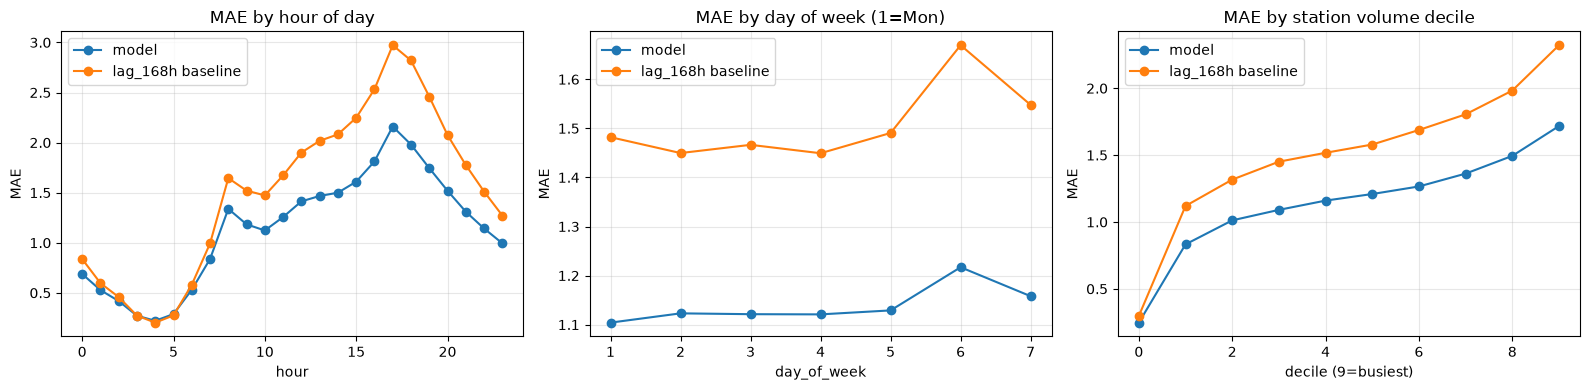

,abs_err,baseline_abs_err,trip_count
hour,,,
0,0.689,0.838,0.739
1,0.527,0.597,0.484
2,0.418,0.458,0.356
3,0.271,0.272,0.182
4,0.221,0.203,0.135
5,0.288,0.275,0.232
6,0.531,0.581,0.649
7,0.838,0.993,1.315
8,1.338,1.645,2.725


In [47]:
# Where does the error concentrate? Peak hours are what matter for rebalancing.
pred = np.clip(hgb.predict(X_test), 0, None)
err = test[["station_id", "hour", "day_of_week", TARGET]].copy()
err["pred"] = pred
err["abs_err"] = (err["pred"] - err[TARGET]).abs()
err["baseline_abs_err"] = (test["lag_168h"].clip(lower=0) - err[TARGET]).abs()

by_hour = err.groupby("hour")[["abs_err", "baseline_abs_err", TARGET]].mean()
by_dow = err.groupby("day_of_week")[["abs_err", "baseline_abs_err"]].mean()

# Station volume deciles: does the model hold up on the busy stations?
station_mean = err.groupby("station_id", observed=True)[TARGET].mean()
err["vol_decile"] = pd.qcut(
    err["station_id"].map(station_mean), 10, labels=False, duplicates="drop"
)
by_decile = err.groupby("vol_decile")[["abs_err", "baseline_abs_err", TARGET]].mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
by_hour[["abs_err", "baseline_abs_err"]].plot(ax=axes[0], marker="o")
axes[0].set(title="MAE by hour of day", xlabel="hour", ylabel="MAE")
by_dow[["abs_err", "baseline_abs_err"]].plot(ax=axes[1], marker="o")
axes[1].set(title="MAE by day of week (1=Mon)", xlabel="day_of_week", ylabel="MAE")
by_decile[["abs_err", "baseline_abs_err"]].plot(ax=axes[2], marker="o")
axes[2].set(title="MAE by station volume decile", xlabel="decile (9=busiest)", ylabel="MAE")
for ax in axes:
    ax.legend(["model", "lag_168h baseline"])
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Attach the error breakdown to the HGB run rather than opening a new one — these
# diagnostics describe that model.
if MLFLOW_ENABLED and HGB_RUN_ID:
    with mlflow.start_run(run_id=HGB_RUN_ID):
        mlflow.log_figure(fig, "diagnostics/error_breakdown.png")
        mlflow.log_table(by_hour.reset_index(), "diagnostics/mae_by_hour.json")
        mlflow.log_table(by_decile.reset_index(), "diagnostics/mae_by_volume_decile.json")
        # Peak-hour MAE is the number ops actually cares about.
        peak = by_hour.loc[[7, 8, 9, 16, 17, 18], "abs_err"].mean()
        mlflow.log_metric("test_MAE_peak_hours", float(peak))

by_hour.round(3)

In [48]:
%%time
# Permutation importance on a subsample — full permutation over 1.3M rows is slow.
# A large lag_168h / roll_mean importance is expected; a large station_id importance
# would suggest the model is memorising levels rather than learning temporal structure.
sample = X_test.sample(n=min(50_000, len(X_test)), random_state=RANDOM_STATE)

imp = permutation_importance(
    hgb, sample, y_test.loc[sample.index],
    scoring="neg_mean_absolute_error",
    n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1,
)

importance = (
    pd.DataFrame({"feature": FEATURES,
                  "importance": imp.importances_mean,
                  "std": imp.importances_std})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

fig_imp, ax = plt.subplots(figsize=(8, 6))
importance.set_index("feature")["importance"].iloc[::-1].plot.barh(
    ax=ax, xerr=importance["std"].iloc[::-1])
ax.set(title="Permutation importance (MAE degradation when shuffled)", xlabel="Δ MAE")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

if MLFLOW_ENABLED and HGB_RUN_ID:
    with mlflow.start_run(run_id=HGB_RUN_ID):
        mlflow.log_figure(fig_imp, "diagnostics/permutation_importance.png")
        mlflow.log_table(importance, "diagnostics/permutation_importance.json")
        mlflow.log_param("importance_sample_rows", len(sample))

importance.round(4)

CPU times: total: 6.36 s
Wall time: 10.6 s


BrokenProcessPool: A task has failed to un-serialize. Please ensure that the arguments of the function are all picklable.

In [ ]:
# Eyeball a busy station over one test week — does the daily shape track?
busiest = station_mean.idxmax()
week = test[(test["station_id"] == busiest)
            & (test["start_date"] >= "2023-06-05")
            & (test["start_date"] < "2023-06-12")].copy()
week["pred"] = np.clip(hgb.predict(week[FEATURES]), 0, None)
week["ts"] = week["start_date"] + pd.to_timedelta(week["hour"], unit="h")

fig_week, axes = plt.subplots(2, 1, figsize=(14, 7))
axes[0].plot(week["ts"], week[TARGET], label="actual", lw=1.8)
axes[0].plot(week["ts"], week["pred"], label="predicted", lw=1.5, alpha=0.85)
axes[0].plot(week["ts"], week["lag_168h"], label="lag_168h baseline", lw=1, ls="--", alpha=0.6)
axes[0].set(title=f"Station {busiest} — test week 2023-06-05", ylabel="trips/hour")
axes[0].legend(); axes[0].grid(alpha=0.3)

residuals = err["pred"] - err[TARGET]
axes[1].hist(residuals, bins=np.arange(-15.5, 16.5), edgecolor="white")
axes[1].set(title=f"Residuals (mean {residuals.mean():+.3f} — bias check)",
            xlabel="predicted - actual", ylabel="count")
axes[1].axvline(0, color="k", lw=1)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

if MLFLOW_ENABLED and HGB_RUN_ID:
    with mlflow.start_run(run_id=HGB_RUN_ID):
        mlflow.log_figure(fig_week, "diagnostics/sample_week_and_residuals.png")
        # Mean residual is the bias check — worth a scalar, not just a chart title.
        mlflow.log_metric("test_residual_mean", float(residuals.mean()))

## Step 8 — Persist

Model + metrics to `ml/artifacts/` (gitignored). The metrics file records the station
subset and feature list so a later scoring run can reproduce the exact input contract —
and the same file is attached to the MLflow run, so the contract travels with the model.

The winning model is then promoted to the **MLflow Model Registry** as
`bike-share-demand-hgb`, but only if it actually beats the `lag_168h` baseline. That gate
is the point of the registry: it is the handoff to Phase 06, and a model that loses to
"same hour last week" has no business being served.

In [ ]:
MODEL_PATH = ARTIFACTS / "model.joblib"
METRICS_PATH = ARTIFACTS / "metrics.json"

joblib.dump(hgb, MODEL_PATH)
joblib.dump(ridge, ARTIFACTS / "ridge.joblib")

metrics = {
    "target": TARGET,
    "features": FEATURES,
    "categorical": CATEGORICAL,
    "excluded": sorted(BANNED),
    "hyperparameters": BEST,
    "n_stations": N_STATIONS,
    "stations": [int(s) for s in TOP_STATIONS],
    "rows": {"train": int(len(train)), "test": int(len(test))},
    "train_period": [str(train["start_date"].min().date()), str(train["start_date"].max().date())],
    "test_period": [str(test["start_date"].min().date()), str(test["start_date"].max().date())],
    "results": leaderboard.reset_index().to_dict(orient="records"),
    "baseline_mae": float(BASELINE_MAE),
    "beats_baseline": bool(best_mae < BASELINE_MAE),
    "mlflow": {"tracking_uri": TRACKING_URI, "experiment": EXPERIMENT, "run_id": HGB_RUN_ID},
}
METRICS_PATH.write_text(json.dumps(metrics, indent=2))

print(f"model   {MODEL_PATH}  ({MODEL_PATH.stat().st_size / 1024**2:.1f} MB)")
print(f"metrics {METRICS_PATH}")

# Attach the input contract + leaderboard to the tracked run.
if MLFLOW_ENABLED and HGB_RUN_ID:
    with mlflow.start_run(run_id=HGB_RUN_ID):
        mlflow.log_artifact(str(METRICS_PATH), artifact_path="contract")
        mlflow.log_table(leaderboard.reset_index(), "contract/leaderboard.json")
        print(f"logged to mlflow run {HGB_RUN_ID}")

In [ ]:
# Round-trip check: the reloaded model must reproduce the test MAE exactly.
reloaded = joblib.load(MODEL_PATH)
reloaded_mae = mean_absolute_error(y_test, np.clip(reloaded.predict(X_test), 0, None))
hgb_mae = next(r["MAE"] for r in results if r["model"] == "HistGradientBoosting")

assert np.isclose(reloaded_mae, hgb_mae), f"{reloaded_mae} != {hgb_mae}"
print(f"round-trip OK — reloaded MAE {reloaded_mae:.6f}")

round-trip OK — reloaded MAE 1.139152


## Step 9 — Register the champion

`joblib` in `ml/artifacts/` is the local copy; the registry is the versioned handoff.
Registering under an **alias** (`champion`) rather than a hard version number means Phase 06
can load `models:/bike-share-demand-hgb@champion` and pick up retrains without a code change.

In [ ]:
REGISTERED_NAME = "bike-share-demand-hgb"

# Register only a model that clears the baseline — see the Step 8 note.
if not (MLFLOW_ENABLED and HGB_RUN_ID):
    print("tracking disabled — nothing to register")
elif best_name != "HistGradientBoosting":
    print(f"leaderboard winner is {best_name!r}, not HistGradientBoosting — not registering")
elif not metrics["beats_baseline"]:
    print(f"MAE {best_mae:.4f} does not beat baseline {BASELINE_MAE:.4f} — not registering")
else:
    version = mlflow.register_model(f"runs:/{HGB_RUN_ID}/model", REGISTERED_NAME)

    client = mlflow.MlflowClient()
    client.set_model_version_tag(REGISTERED_NAME, version.version, "test_MAE", f"{best_mae:.4f}")
    client.set_model_version_tag(REGISTERED_NAME, version.version, "beats_baseline", "true")
    client.update_model_version(
        REGISTERED_NAME, version.version,
        description=(f"HGB on top {N_STATIONS} stations. Test-2023 MAE {best_mae:.4f} "
                     f"vs lag_168h baseline {BASELINE_MAE:.4f} "
                     f"({(BASELINE_MAE - best_mae) / BASELINE_MAE:+.1%})."),
    )
    # Alias, not a stage — stages are deprecated in MLflow 2.x.
    client.set_registered_model_alias(REGISTERED_NAME, "champion", version.version)

    print(f"registered {REGISTERED_NAME} v{version.version} (alias: champion)")
    print(f"load with: mlflow.sklearn.load_model('models:/{REGISTERED_NAME}@champion')")
    print(f"UI: {TRACKING_URI}/#/models/{REGISTERED_NAME}")